# Final EDA: Evaluating our main dataset

### Imports

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Loading Data

In [3]:
finalData = pd.read_csv('C:/Users/finco/Documents/GitHub/DS496Capstone/Processed Data/finalData.csv')
finalData = finalData[finalData['year'] != 2026]
finalData

,year,state_po,district,CollegeGrad,MedianAge,Hispanic,White,Black,NativeAmerican,Asian,republican_victory,republican_president,midterm,republican_incumbent,pvi
0,2012,AL,1,22.20,38.7,2.9,65.6,27.6,1.1,1.4,True,False,False,True,14.63
1,2012,AL,2,21.60,37.8,3.4,63.4,29.8,0.3,1.3,True,False,False,True,18.21
2,2012,AL,3,20.20,37.3,2.7,68.8,25.8,0.3,1.3,True,False,False,True,15.91
3,2012,AL,4,15.20,40.6,5.0,84.6,7.1,0.5,0.7,True,False,False,True,25.14
4,2012,AL,5,30.10,38.9,4.9,73.6,17.0,0.7,1.4,True,False,False,True,15.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2837,2024,WI,5,41.55,43.0,6.0,85.9,1.8,0.1,3.0,True,False,False,True,14.29
2838,2024,WI,6,30.01,42.7,6.0,86.0,2.0,0.3,2.6,True,False,False,True,10.24
2839,2024,WI,7,26.71,45.3,3.0,89.4,0.4,1.6,1.5,True,False,False,True,12.27
2840,2024,WI,8,29.29,41.5,6.7,83.7,1.5,1.8,2.5,True,False,False,True,10.16


### Plot Settings

In [4]:
plt.rcParams['font.family'] = 'Times New Roman'
sns.set_palette("crest")

### Summary Statistics

In [5]:
finalData.describe()

,year,district,CollegeGrad,MedianAge,Hispanic,White,Black,NativeAmerican,Asian,pvi
count,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000
mean,2017.796622,10.133709,31.781847,38.391837,15.667523,53.497396,10.180647,0.626566,5.284096,-0.307558
std,3.978756,10.804317,10.907874,3.605329,18.019589,28.592978,13.164155,1.774607,6.444042,16.119849
min,2012.000000,0.000000,7.800000,27.500000,0.000000,0.200000,0.000000,0.000000,0.300000,-44.200000
25%,2014.000000,3.000000,23.800000,36.100000,3.500000,29.600000,1.900000,0.100000,1.700000,-11.560000
50%,2018.000000,6.000000,29.965000,38.400000,9.300000,61.500000,5.100000,0.200000,3.300000,2.130000
75%,2022.000000,13.000000,38.235000,40.600000,20.600000,76.800000,12.575000,0.500000,5.800000,12.267500
max,2024.000000,53.000000,74.090000,56.000000,90.600000,96.100000,67.100000,23.500000,58.400000,33.570000


### PVI

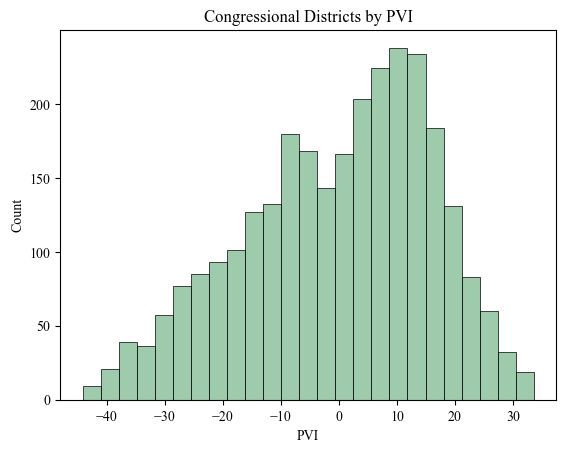

In [6]:
sns.histplot(data=finalData['pvi'], bins=25, linewidth = 0.5)
plt.title('Congressional Districts by PVI')
plt.xlabel('PVI')
plt.show()

### Education

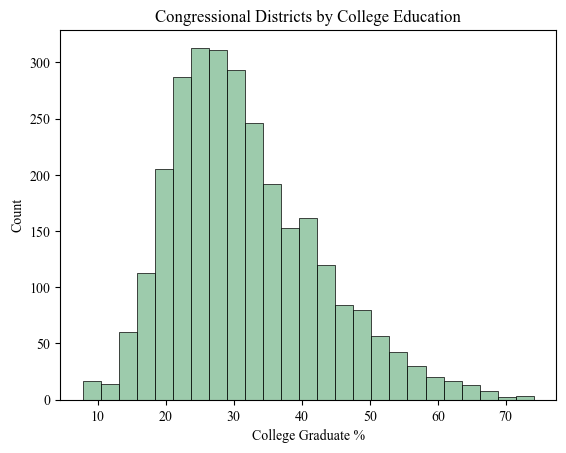

In [7]:
sns.histplot(data=finalData['CollegeGrad'], bins=25, linewidth = 0.5)
plt.title('Congressional Districts by College Education')
plt.xlabel('College Graduate %')
plt.show()

### Race/Ethnicity

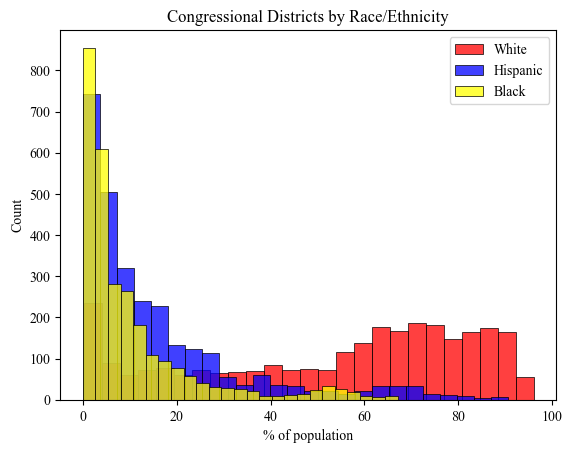

In [8]:
sns.histplot(data=finalData['White'], bins=25, linewidth = 0.5, label='White', color='red')
sns.histplot(data=finalData['Hispanic'], bins=25, linewidth = 0.5, label='Hispanic', color='blue')
sns.histplot(data=finalData['Black'], bins=25, linewidth = 0.5, label = 'Black', color='yellow')
plt.title('Congressional Districts by Race/Ethnicity')
plt.xlabel('% of population')
plt.legend()
plt.show()

### Age

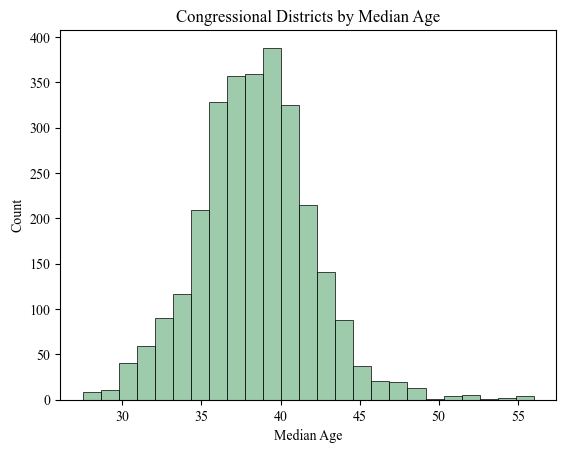

In [9]:
sns.histplot(data=finalData['MedianAge'], bins=25, linewidth = 0.5)
plt.title('Congressional Districts by Median Age')
plt.xlabel('Median Age')
plt.show()

### Midterm and Republican Victory

[True False]


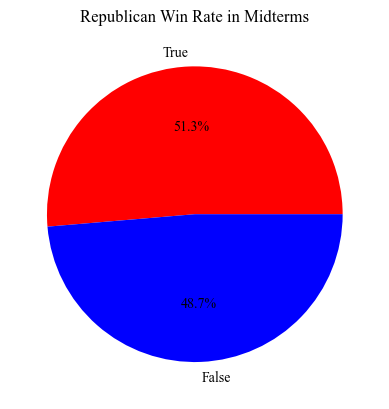

In [ ]:
midterm_data = finalData[finalData['midterm'] == True]  #

counts = midterm_data['republican_victory'].value_counts()

fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['red', 'blue'])

ax.set_title('Republican Win Rate in Midterms')

plt.show()

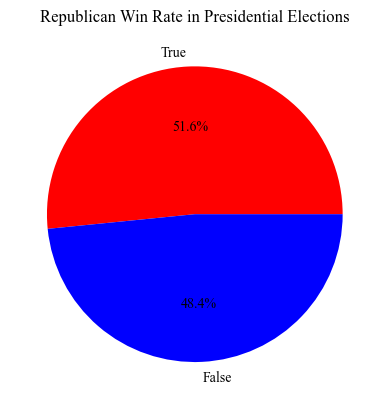

In [34]:
pres_data = finalData[finalData['midterm'] == False]  #

counts = pres_data['republican_victory'].value_counts()

fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['red', 'blue'])

ax.set_title('Republican Win Rate in Presidential Elections')

plt.show()

### Republican President and Republican Victory

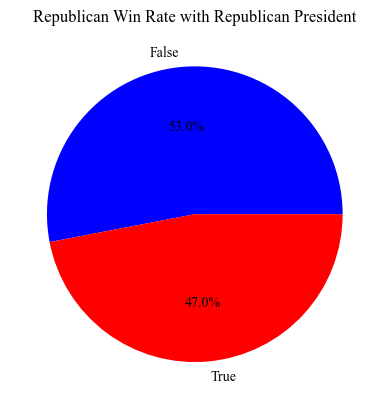

In [ ]:
repPres_data = finalData[finalData['republican_president'] == True]  #

counts = repPres_data['republican_victory'].value_counts()

fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['blue', 'red'])

ax.set_title('Republican Win Rate with Republican President')

plt.show()

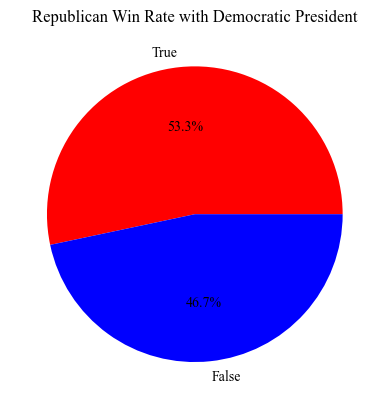

In [38]:
demPres_data = finalData[finalData['republican_president'] == False]  

counts = demPres_data['republican_victory'].value_counts()

fig, ax = plt.subplots()
ax.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['red', 'blue'])

ax.set_title('Republican Win Rate with Democratic President')

plt.show()

### Correlation Heatmap

<Axes: >

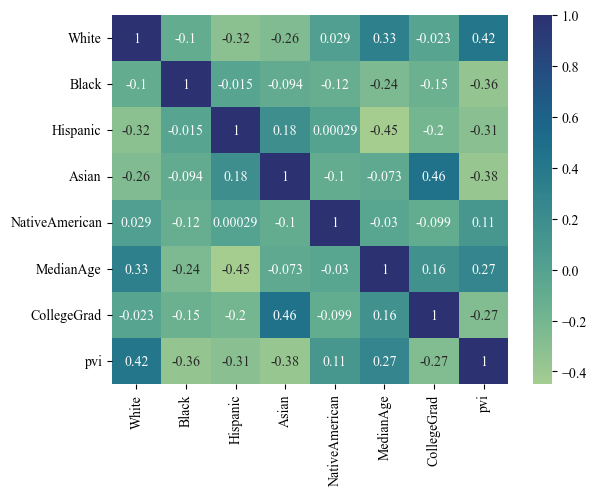

In [11]:
corrMatrix = finalData[['White', 'Black', 'Hispanic', 'Asian', 'NativeAmerican', 'MedianAge', 'CollegeGrad', 'pvi']].corr()

sns.heatmap(corrMatrix, annot=True, cmap='crest')

### Pair Plot

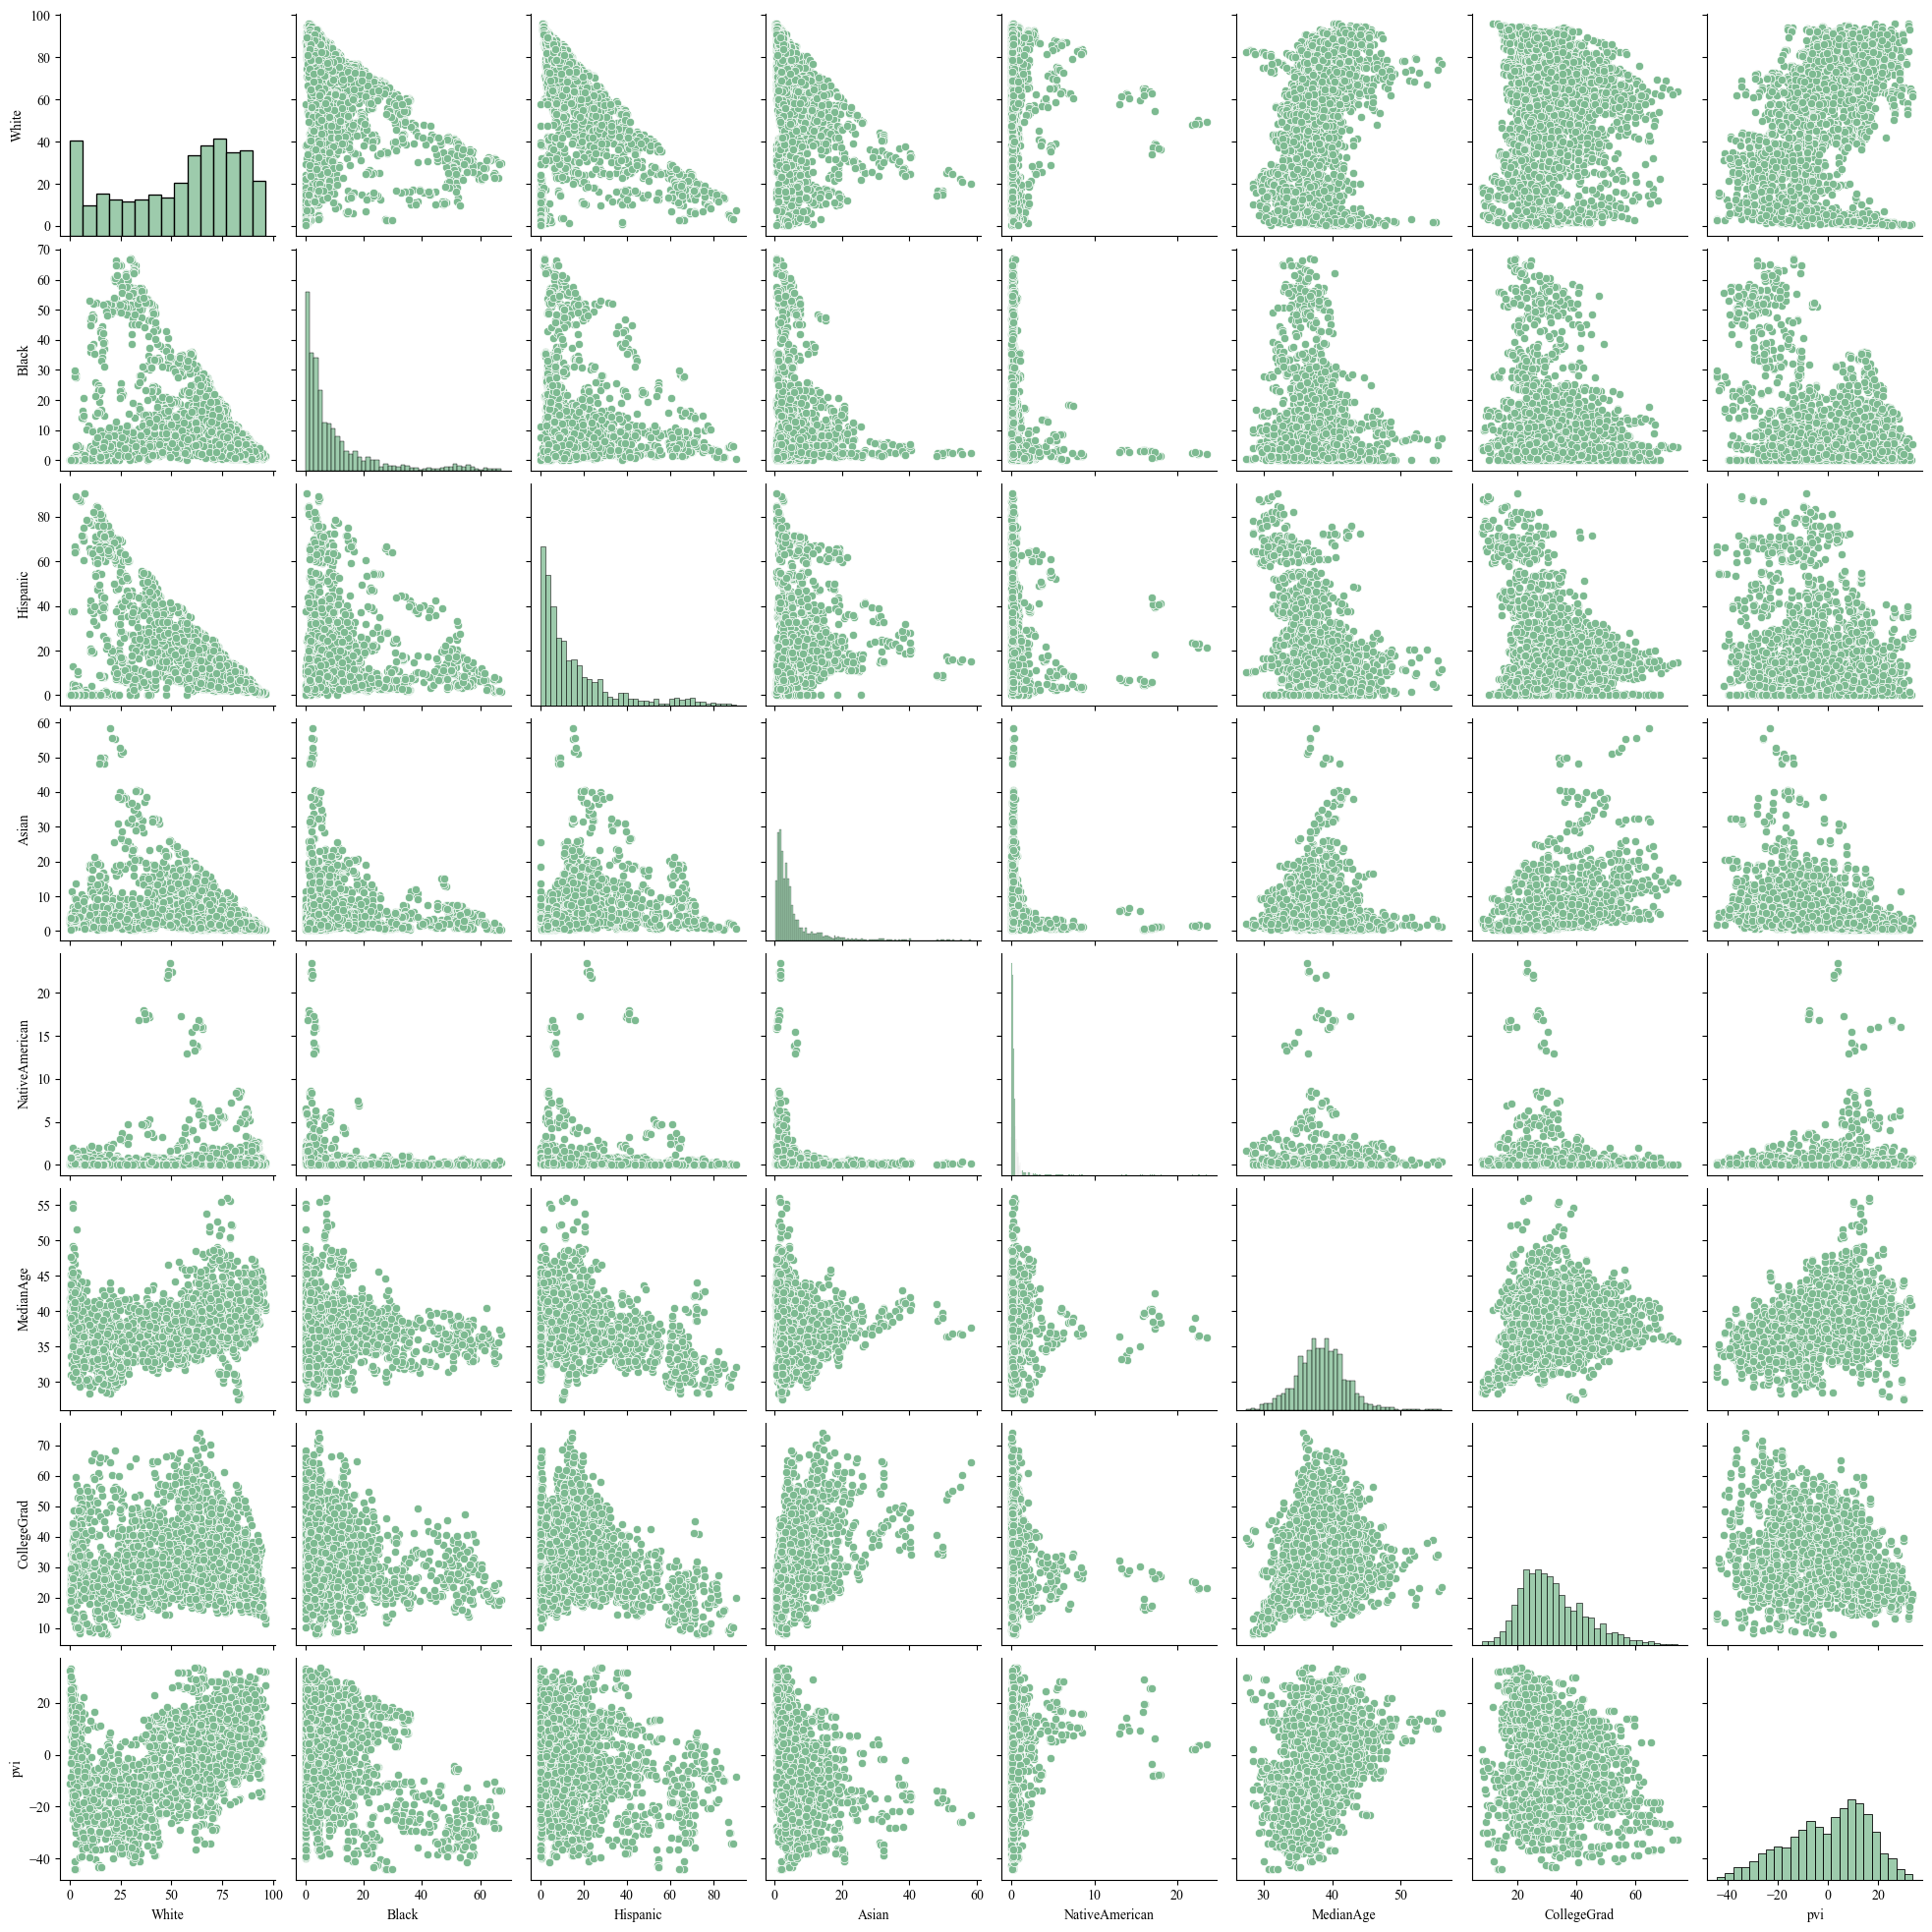

In [12]:
sns.pairplot(data=finalData[['White', 'Black', 'Hispanic', 'Asian', 'NativeAmerican', 'MedianAge', 'CollegeGrad', 'pvi']])